In [1]:
try:
  %matplotlib ipympl
except:
  pass


In [2]:
import os, sys, subprocess

REPO = "https://github.com/jongmoonha/Train_fault_simulation.git"
DIR  = "Train_fault_simulation"

try:
    import google.colab  # Colab 전용 모듈
    if not os.path.isdir(DIR):
        subprocess.run(["git","clone",REPO], check=True)
    print('We are in Google Colab environment.')
    os.chdir('/content/'+DIR)
    print('Current working directory:', os.getcwd())

except ImportError:
    print('We are in a local environment, not Google Colab.')
    pass

We are in a local environment, not Google Colab.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.stats import kurtosis

from utils.utils_processing import fft_simple, filtering, get_fault_frequency, fault_repeat_uncertainty, generate_unit_impulse_response, envelope_spectrum_band, real_cepstrum
from utils.utils_plot import plot_raw, plot_spectrum, five_harmonics, plot_cepstrum
from utils import kurtogram as kg

In [4]:
import mat73

%matplotlib widgetmal Signal (or Import the Signal)

# Configuration for the Generation

In [5]:
config = {
    'condition': 'I',      # 'I' | 'O' | 'B'
    'fs': 51200,
    'T' : 20,
    'segments': 50,
    'speed_rpm': 1350,     # shaft speed
    'Bd': 7.6, 'Nb': 8, 'd1': 20, 'd2': 47, 'a': 0,
    'beta_range': (4000, 8000),
    'fn_range': (12000, 12010),
    'fault_amp': 0.3,
    'A_normal': 0.2, # 0.1 for Inner, 0.2 for outer, 
    'nlevel' : 7,
    'nlevel_seg' : 4,
}

# Normal Signal Import

In [6]:
dir = './data_field/'
filename = 'Log.mat'

dir_file = dir + filename
data = mat73.loadmat(dir_file)

v_tot = data['Log']['rawdata']  # vibration signal
fs = 51200  # sampling frequency
t = np.arange(len(v_tot)) / fs  # time vector
N = len(v_tot)  # number of samples
T = t[-1]

# Signal Info
print('Signal Info:')
print(f'  Sampling Frequency: {fs} Hz')
print(f'  Signal Length: {N} samples ({T:.3f} sec)')

Signal Info:
  Sampling Frequency: 51200 Hz
  Signal Length: 1536001 samples (30.000 sec)


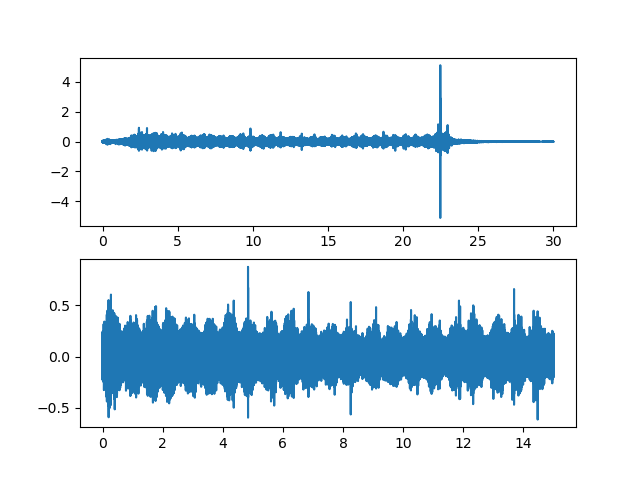

In [7]:
ch = 0
x_normal = v_tot[:, ch]
t = t = np.arange(len(x_normal)) / fs  # time vector
N = len(x_normal)

plt.figure()
plt.subplot(2,1,1)
plt.plot(t, x_normal)

x_normal = x_normal[(t<20) & (t>5)]
t = t = np.arange(len(x_normal)) / fs  # time vector
N = len(x_normal)

plt.subplot(2,1,2)
plt.plot(t, x_normal)

# Fault Signal Generation

### Fault Feature

### Fault Signal

In [8]:
rng = np.random.default_rng(0)

# Fault Characteristic Frequency
fault_freq, FTF, FCF, unit = get_fault_frequency(config)
fr = config['speed_rpm']/60
print(f'Rotational frequency: {fr:.1f} Hz')
print(f'freq_w_fault_featurey: {fault_freq:.1f} Hz')

# Unit impulse response
unit_fault_feature, Beta, Fn = generate_unit_impulse_response(t, config['beta_range'], config['fn_range'], rng)

# Synthesized Faulty Signal
x_fault_feature = fault_repeat_uncertainty(unit_fault_feature, FCF, fr, t, fs, FTF, config['condition']) * config['fault_amp']
x_fault_signal = x_normal + x_fault_feature

Rotational frequency: 22.5 Hz
freq_w_fault_featurey: 110.4 Hz


### Raw, Spectrum, Env

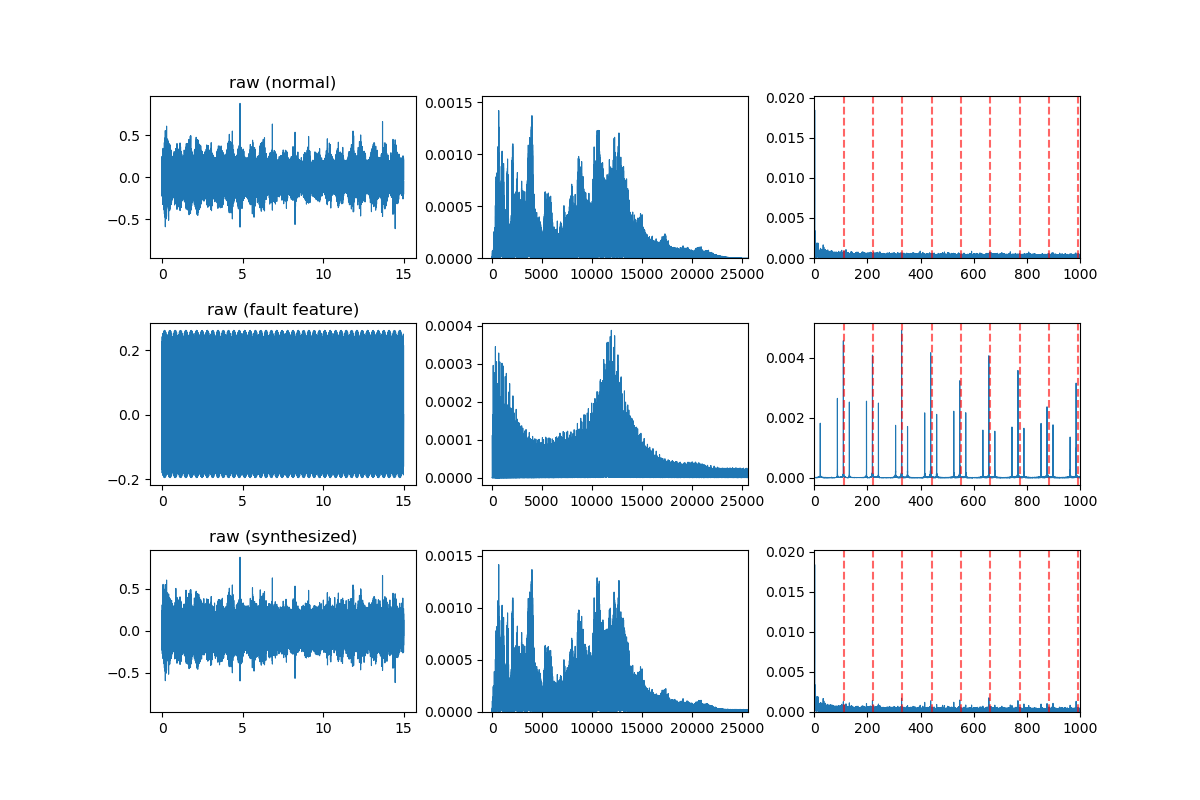

In [9]:
# 4-1~4-12) Plots
fig, axs = plt.subplots(3, 3, figsize=(12, 8))
axs = axs.ravel()

ymax = np.max(x_fault_signal)
plot_raw(axs[0], t, x_normal, 'raw (normal)'); axs[0].set_ylim([-1.1*ymax, 1.1*ymax])
plot_raw(axs[3], t, x_fault_feature, 'raw (fault feature)')
plot_raw(axs[6], t, x_fault_signal, 'raw (synthesized)'); axs[6].set_ylim([-1.1*ymax, 1.1*ymax])

xlim = [-1000, fs/2]
ymax = 1.1*np.max(fft_simple(x_fault_signal-np.mean(x_fault_signal), fs)[1])

plot_spectrum(axs[1], x_normal, fs, 'spectrum (normal)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[4], x_fault_feature, fs, 'spectrum (fault feature)', xlim=xlim)
plot_spectrum(axs[7], x_fault_signal, fs, 'spectrum (synth)', xlim=xlim, ylim=ymax)

xlim = [0, 1000]
harmonic_lines = [h for h in five_harmonics(fault_freq, n=10) if h <= 1000]
env = np.abs(hilbert(x_fault_signal))
ymax = 1.1*np.max(fft_simple(env-np.mean(env), fs)[1])

plot_spectrum(axs[2], np.abs(hilbert(x_normal)), fs, 'env spectrum (normal)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[5], np.abs(hilbert(x_fault_feature)), fs, 'env spectrum (fault feature)', harmonic_lines, xlim=xlim)
plot_spectrum(axs[8], np.abs(hilbert(x_fault_signal)), fs, 'env spectrum (synth)', harmonic_lines, xlim=xlim, ylim=ymax)

# add margins between subplots (axes)
plt.subplots_adjust(hspace=0.4, wspace=0.25)
plt.show()


# Kurtogram and Envelope Analysis w/ Band-pass Filtering

In [10]:
nlevel = config['nlevel']
Kwav_norm, Level_w_norm, freq_w_norm, c_norm, maxK_norm, bw_norm, lvl_norm, Wn_norm = kg.fast_kurtogram(x_normal, fs, nlevel=nlevel)
Kwav_fault_feature, Level_w_fault_feature, freq_w_fault_feature, c_fault_feature, maxK_fault_feature, bw_fault_feature, lvl_fault_feature, Wn_fault_feature = kg.fast_kurtogram(x_fault_feature, fs, nlevel=nlevel)
Kwav_fault_signal, Level_w_fault_signal, freq_w_fault_signal, c_fault_signal, maxK_fault_signal, bw_fault_signal, lvl_fault_signal, Wn_fault_signal = kg.fast_kurtogram(x_fault_signal, fs, nlevel=nlevel)
f_e_n, A_e_n, env_n, xf_n = envelope_spectrum_band(x_normal, fs, Wn_norm)
f_e_f, A_e_f, env_f, xf_f = envelope_spectrum_band(x_fault_feature, fs, Wn_fault_feature)
f_e_s, A_e_s, env_s, xf_s = envelope_spectrum_band(x_fault_signal, fs, Wn_fault_signal)

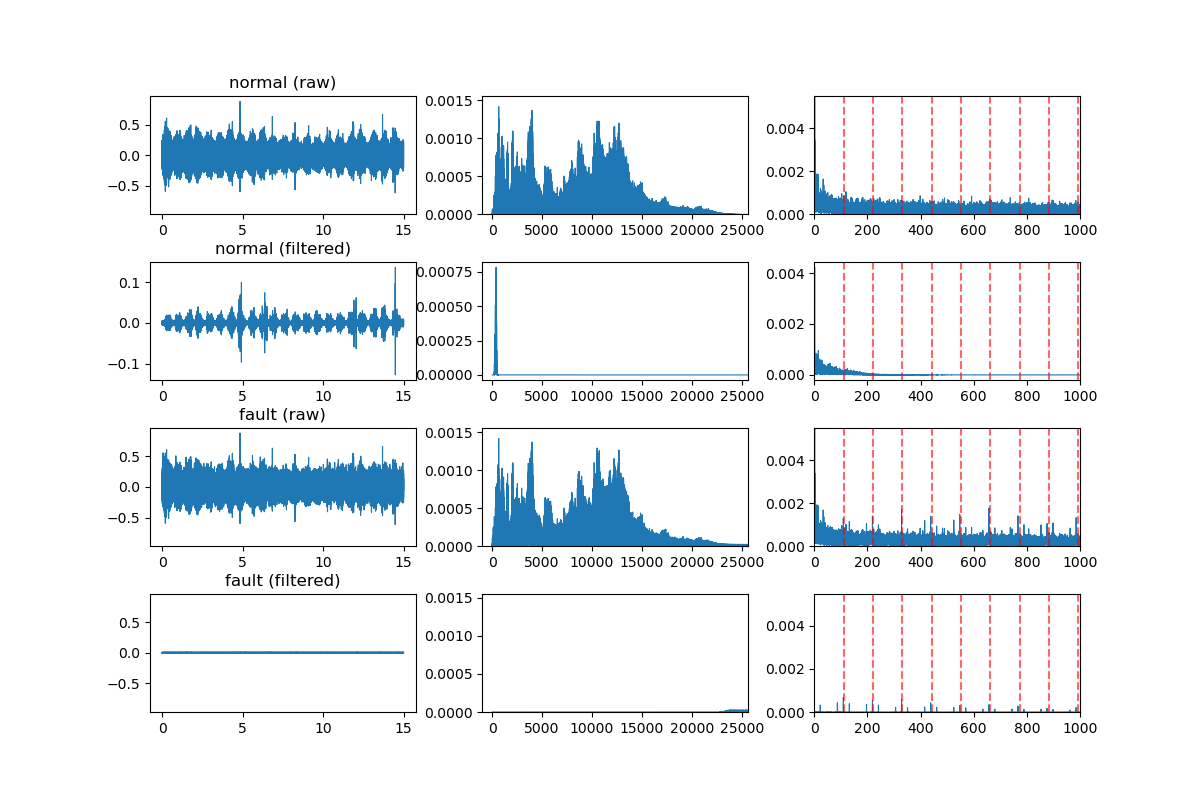

In [11]:
fig, axs = plt.subplots(4, 3, figsize=(12, 8))
axs = axs.ravel()

ymax = np.max(x_fault_signal)
plot_raw(axs[0], t, x_normal, 'normal (raw)'); axs[0].set_ylim([-1.1*ymax, 1.1*ymax])
plot_raw(axs[3], t, xf_n, 'normal (filtered)')
plot_raw(axs[6], t, x_fault_signal, 'fault (raw)'); axs[6].set_ylim([-1.1*ymax, 1.1*ymax])
plot_raw(axs[9], t, xf_s, 'fault (filtered)'); axs[9].set_ylim([-1.1*ymax, 1.1*ymax])

xlim = [-1000, fs/2]
ymax = 1.1*np.max(fft_simple(x_fault_signal-np.mean(x_fault_signal), fs)[1])

plot_spectrum(axs[1], x_normal, fs, 'normal spectrum (raw)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[4], xf_n, fs, 'normal spectrum (filtered)', xlim=xlim)
plot_spectrum(axs[7], x_fault_signal, fs, 'fault spectrum (raw)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[10], xf_s, fs, 'fault spectrum (filtered)', xlim=xlim, ylim=ymax)

xlim = [0, 1000]
harmonic_lines = [h for h in five_harmonics(fault_freq, n=10) if h <= 1000]
x_fault_env = np.abs(hilbert(x_fault_signal))
ymax = 0.3*np.max(fft_simple(x_fault_env-np.mean(x_fault_env), fs)[1])

plot_spectrum(axs[2], np.abs(hilbert(x_normal)), fs, 'normal env spectrum (raw)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[5], np.abs(hilbert(xf_n)), fs, 'normal env spectrum (filtered)', harmonic_lines, xlim=xlim)
plot_spectrum(axs[8], np.abs(hilbert(x_fault_signal)), fs, 'fault env spectrum (raw)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[11], np.abs(hilbert(xf_s)), fs, 'fault env spectrum (filtered)', harmonic_lines, xlim=xlim, ylim=ymax)

# add margins between subplots (axes)
plt.subplots_adjust(hspace=0.4, wspace=0.25)
plt.show()


# Feature Visualization

### Kurtogram

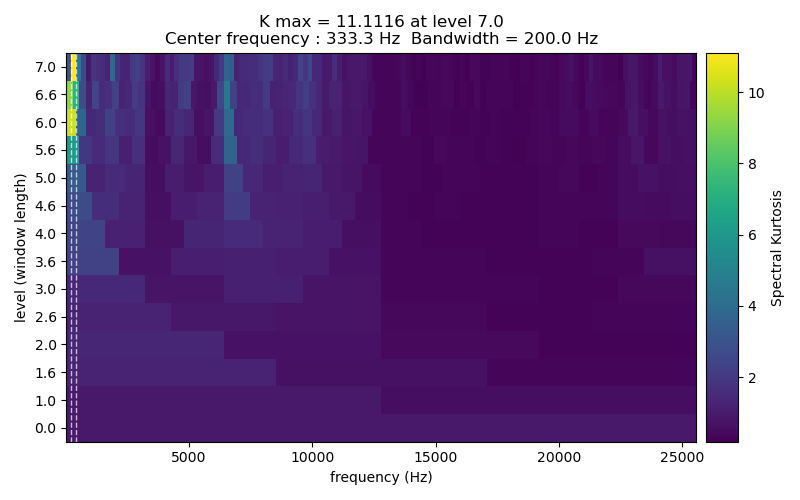

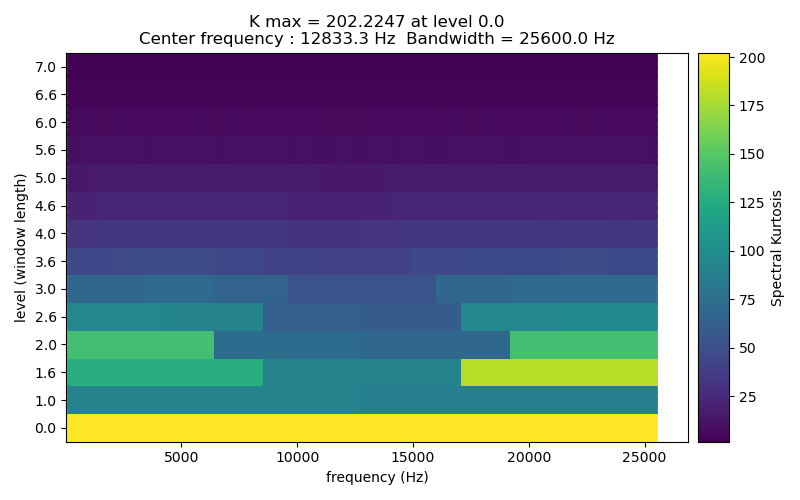

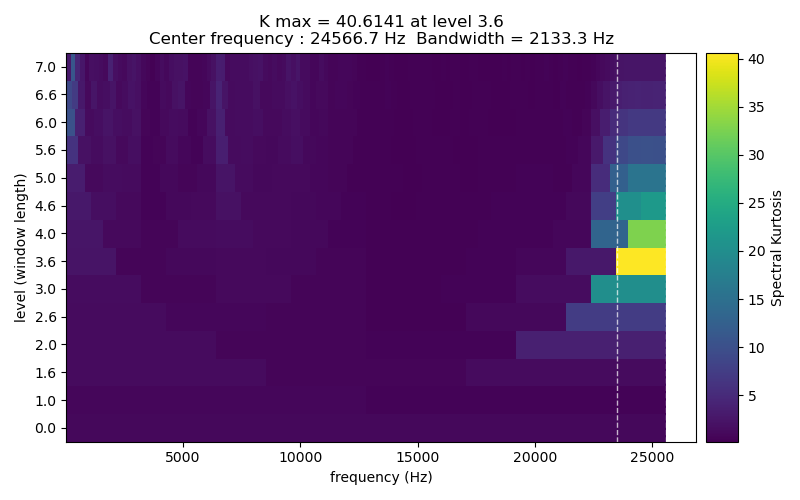

In [ ]:
# Show kurtograms (optional visual)
kg.plot_kurtogram(Kwav_norm, Level_w_norm, maxK_norm, bw_norm, lvl_norm, fs, Wn_norm)
kg.plot_kurtogram(Kwav_fault_feature, Level_w_fault_feature, maxK_fault_feature, bw_fault_feature, lvl_fault_feature, fs, Wn_fault_feature)
kg.plot_kurtogram(Kwav_fault_signal, Level_w_fault_signal, maxK_fault_signal, bw_fault_signal, lvl_fault_signal, fs, Wn_fault_signal)

### Envelope Spectrum

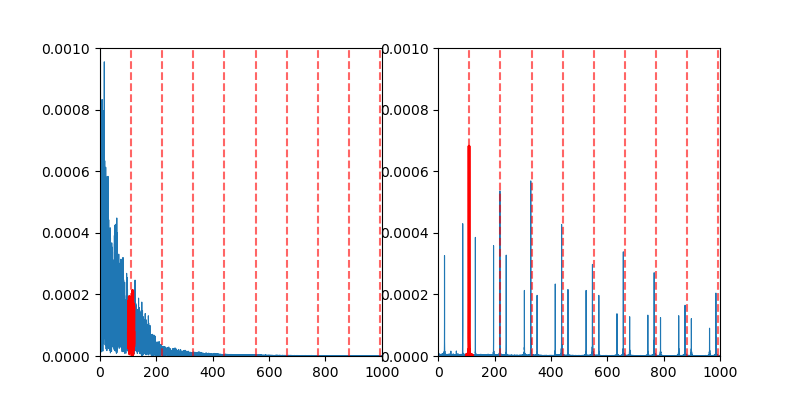

In [ ]:
f_range = 10
idx_range = np.where((f >= fault_freq-f_range) & (f <= fault_freq+f_range))[0]

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

env = np.abs(hilbert(xf_n))
f, A = fft_simple(env-np.mean(env), fs)
plot_spectrum(ax[0], np.abs(hilbert(xf_n)), fs, 'fault env spectrum (filtered)', harmonic_lines, xlim=xlim, ylim=0.001)
ax[0].plot(f[idx_range], A[idx_range], color='r', linewidth=2)

env = np.abs(hilbert(xf_s))
f, A = fft_simple(env-np.mean(env), fs)
plot_spectrum(ax[1], np.abs(hilbert(xf_s)), fs, 'fault env spectrum (filtered)', harmonic_lines, xlim=xlim, ylim=0.001)
ax[1].plot(f[idx_range], A[idx_range], color='r', linewidth=2)

### Cepstrum

In [ ]:
1/fault_freq

np.float64(0.009056501757231685)

In [37]:
cep_x-t

array([0., 0., 0., ..., 0., 0., 0.])

In [35]:
t

array([0.00000000e+00, 1.95312500e-05, 3.90625000e-05, ...,
       1.49999219e+01, 1.49999414e+01, 1.49999609e+01])

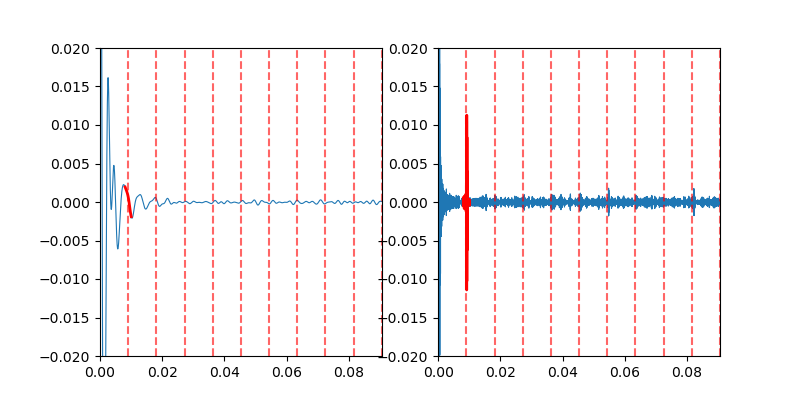

In [ ]:
cep_n = real_cepstrum(xf_n-np.mean(xf_n))
cep_f = real_cepstrum(xf_s-np.mean(xf_s))
cep_x = np.arange(len(cep_n)) / fs

vlines = [h for h in five_harmonics(1/fault_freq, n=10) if h <= 1000]

cep_x_range = 0.001
idx_range = np.where((cep_x >= 1/fault_freq-cep_x_range) & (cep_x <= 1/fault_freq+cep_x_range))[0]

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

env = np.abs(hilbert(xf_n))
plot_cepstrum(ax[0], cep_x, cep_n, title='cepstrum (normal filtered)', vlines=vlines, xlim=[0, 1/fault_freq * 10], ylim=[-0.02, 0.02])
ax[0].plot(cep_x[idx_range], cep_n[idx_range], color='r', linewidth=2)

env = np.abs(hilbert(xf_s))
plot_cepstrum(ax[1], cep_x, cep_f, title='cepstrum (fault filtered)', vlines=vlines, xlim=[0, 1/fault_freq * 10], ylim=[-0.02, 0.02])
ax[1].plot(cep_x[idx_range], cep_f[idx_range], color='r', linewidth=2)

# Feature Calculation from each Segment

In [ ]:
S = config['segments']
L = N//S

def segments(x):
    return x[:S*L].reshape(S, L)

seg_n = segments(x_normal)
seg_f = segments(x_fault_signal)

print(f'The number of segments: {S}, segment length: {L} samples ({L/fs:.3f} sec)')

The number of segments: 50, segment length: 15359 samples (0.300 sec)


In [46]:
import importlib
import utils.utils_processing as up
importlib.reload(up)

from utils.utils_processing import def_features


In [47]:
nlevel_seg = config['nlevel_seg']

feat_n = []
for v in seg_n:
    feat, feat_names = def_features(v, fs, fault_freq, nlevel_seg)
    feat_n.append(feat)
feat_n = np.array(feat_n)

feat_f = []
for v in seg_f:
    feat, feat_names = def_features(v, fs, fault_freq, nlevel_seg)
    feat_f.append(feat)
feat_f = np.array(feat_f)

In [ ]:


###############################################################
##################### Basic statistics per segment ####################
###############################################################
k_n = kurtosis(seg_n, axis=1, fisher=False)
k_f = kurtosis(seg_f, axis=1, fisher=False)

###############################################################
## Max kurtosis from kurtogram per segment (adaptive level) ###
###############################################################
maxK_n = []
maxK_f = []
Wn_norm = []
Wn_fault_signal = []
for xn, xf in zip(seg_n, seg_f):
    _, _, _, _, maxK_n_, _, _, Wn_norm_ = kg.fast_kurtogram(xn, fs, nlevel=nlevel_seg)
    _, _, _, _, maxK_f_, _, _, Wn_fault_signal_ = kg.fast_kurtogram(xf, fs, nlevel=nlevel_seg)

    maxK_n.append(maxK_n_)
    maxK_f.append(maxK_f_)
    Wn_norm.append(Wn_norm_)
    Wn_fault_signal.append(Wn_fault_signal_)

maxK_n = np.array(maxK_n)
maxK_f = np.array(maxK_f)

# Fault-line amplitude at envelope spectrum from band-pass filtered signal (0-30 Hz region)
amp_env_n = []
amp_env_f = []
for xn, xf, Wn_n, Wn_f in zip(seg_n, seg_f, Wn_norm, Wn_fault_signal):
    # derive band from full-signal kurtogram once (reuse bandw,bw computed earlier)
    f, A, _, _ = envelope_spectrum_band(xf, fs, Wn_f)
    # Energy around fault frequency (range +- nn Hz)
    f_range = 10
    idx_range = np.where((f >= fault_freq-f_range) & (f <= fault_freq+f_range))[0]
    amp_env_f.append(np.mean(A[idx_range])/np.mean(A))

    f, A, _, _ = envelope_spectrum_band(xn, fs, Wn_n)
    idx_range = np.where((f >= fault_freq-f_range) & (f <= fault_freq+f_range))[0]
    amp_env_n.append(np.mean(A[idx_range])/np.mean(A))
amp_env_n = np.array(amp_env_n)
amp_env_f = np.array(amp_env_f)


In [ ]:
S = config['segments']
L = N//S

def segments(x):
    return x[:S*L].reshape(S, L)

seg_n = segments(x_normal)
seg_f = segments(x_fault_signal)

print(f'The number of segments: {S}, segment length: {L} samples ({L/fs:.3f} sec)')



###############################################################
##################### Basic statistics per segment ####################
###############################################################
k_n = kurtosis(seg_n, axis=1, fisher=False)
k_f = kurtosis(seg_f, axis=1, fisher=False)

###############################################################
## Max kurtosis from kurtogram per segment (adaptive level) ###
###############################################################
nlevel_seg = config['nlevel_seg']
maxK_n = []
maxK_f = []
Wn_norm = []
Wn_fault_signal = []
for xn, xf in zip(seg_n, seg_f):
    _, _, _, _, maxK_n_, _, _, Wn_norm_ = kg.fast_kurtogram(xn, fs, nlevel=nlevel_seg)
    _, _, _, _, maxK_f_, _, _, Wn_fault_signal_ = kg.fast_kurtogram(xf, fs, nlevel=nlevel_seg)

    maxK_n.append(maxK_n_)
    maxK_f.append(maxK_f_)
    Wn_norm.append(Wn_norm_)
    Wn_fault_signal.append(Wn_fault_signal_)

maxK_n = np.array(maxK_n)
maxK_f = np.array(maxK_f)

# Fault-line amplitude at envelope spectrum from band-pass filtered signal (0-30 Hz region)
amp_env_n = []
amp_env_f = []
for xn, xf, Wn_n, Wn_f in zip(seg_n, seg_f, Wn_norm, Wn_fault_signal):
    # derive band from full-signal kurtogram once (reuse bandw,bw computed earlier)
    f, A, _, _ = envelope_spectrum_band(xf, fs, Wn_f)
    # Energy around fault frequency (range +- nn Hz)
    f_range = 10
    idx_range = np.where((f >= fault_freq-f_range) & (f <= fault_freq+f_range))[0]
    amp_env_f.append(np.mean(A[idx_range])/np.mean(A))

    f, A, _, _ = envelope_spectrum_band(xn, fs, Wn_n)
    idx_range = np.where((f >= fault_freq-f_range) & (f <= fault_freq+f_range))[0]
    amp_env_n.append(np.mean(A[idx_range])/np.mean(A))
amp_env_n = np.array(amp_env_n)
amp_env_f = np.array(amp_env_f)


The number of segments: 50, segment length: 15359 samples (0.300 sec)


# Feature Comparison (Normal vs Fault)

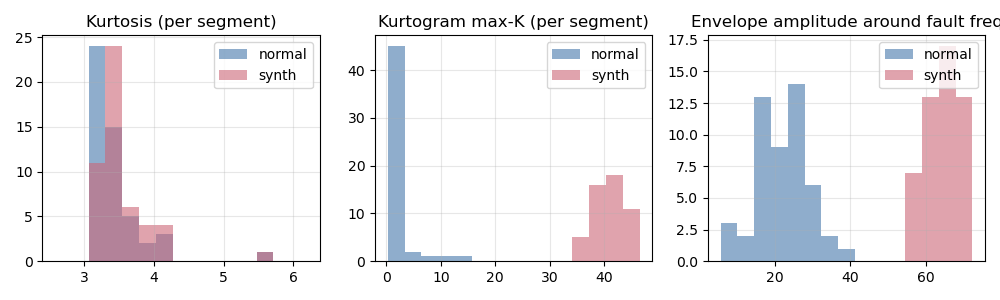

In [18]:
# Histogram comparison: kurtosis, kurtogram max-K, envelope amplitude (shared bins & clear styles)
fig, axs = plt.subplots(1, 3, figsize=(10, 3))
axs = axs.ravel()
# 1) Kurtosis per segment
bins_k = np.linspace(min(k_n.min(), k_f.min()) - 0.5, max(k_n.max(), k_f.max()) + 0.5, 16)
axs[0].hist(k_n, bins=bins_k, color="#4477AA", alpha=0.6, label='normal')
axs[0].hist(k_f, bins=bins_k, color='#CC6677', alpha=0.6,  label='synth')
axs[0].set_title('Kurtosis (per segment)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)
# 2) kurtogram max-K per segment
# ensure arrays are finite
mk_min = np.nanmin(np.hstack([maxK_n, maxK_f]))
mk_max = np.nanmax(np.hstack([maxK_n, maxK_f]))
bins_mk = np.linspace(mk_min - 0.01, mk_max + 0.01, 16)
axs[1].hist(maxK_n, bins=bins_mk, color='#4477AA', alpha=0.6, label='normal')
axs[1].hist(maxK_f, bins=bins_mk, color='#CC6677', alpha=0.6, label='synth')
axs[1].set_title('Kurtogram max-K (per segment)')
axs[1].legend()
axs[1].grid(True, alpha=0.3)
# 3) Envelope amplitude around fault frequency
bins_env = np.linspace(min(amp_env_n.min(), amp_env_f.min()) - 1e-12, max(amp_env_n.max(), amp_env_f.max()) + 1e-12, 16)
axs[2].hist(amp_env_n, bins=bins_env, color='#4477AA', alpha=0.6, label='normal')
axs[2].hist(amp_env_f, bins=bins_env, color='#CC6677', alpha=0.6, label='synth')
axs[2].set_title('Envelope amplitude around fault freq')
axs[2].legend()
axs[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()